# Build a Mini vLLM: Paged KV Cache and Continuous Batching From Scratch

Serving an LLM is a memory-management problem wearing a deep-learning costume. The KV cache —
not the weights — decides how many requests fit on a GPU, and how you schedule requests decides
how much of the hardware you waste. [vLLM](https://github.com/vllm-project/vllm) reframed both
with two ideas borrowed from operating systems:

1. **PagedAttention** ([Kwon et al., SOSP 2023](https://arxiv.org/abs/2309.06180)) — store each
   sequence's KV cache in small non-contiguous *blocks* (like virtual-memory pages) instead of
   one big reserved slab, eliminating the 60–80% memory waste of naive serving.
2. **Continuous batching** — admit and retire requests at *token* granularity instead of waiting
   for a whole batch to finish, so the batch stays full and decode hardware stays busy.

This chapter builds both, from scratch, in ~150 lines on this repo's transformer layers — with a
correctness proof against contiguous attention, measured memory waste, measured batch occupancy,
and real preemption when the block pool runs dry.

### Concepts covered

| # | Concept | Section |
|---|---------|---------|
| 1 | Why the KV cache dominates serving memory | §1 |
| 2 | Block pool + block tables (paged KV cache) | §2 |
| 3 | PagedAttention, verified against contiguous attention | §3–4 |
| 4 | The engine: admission, decode, retirement | §5 |
| 5 | Memory waste: reserved vs allocated vs used | §6 |
| 6 | Static vs continuous batching (occupancy, steps) | §7 |
| 7 | Preemption by recompute when memory runs out | §8 |

::: {.callout-tip title="📺 Video companion"}
[Fast LLM Serving with vLLM and PagedAttention (Anyscale)](https://www.youtube.com/watch?v=5ZlavKF_98U)
is the vLLM authors presenting exactly these two ideas; for the memory-math background first, see
[The KV Cache: Memory Usage in Transformers (Efficient NLP)](https://www.youtube.com/watch?v=80bIUggRJf4)
— more in [Videos](../../docs/VIDEOS.md).
:::

<a href="https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/04_inference_optimization/00_mini_vllm.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/></a>

Runs on CPU — the model is tiny (untrained, seeded) because the lessons here are about *memory and scheduling*, not model quality.

In [1]:
#| code-fold: true
#| code-summary: "Setup"
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

%config InlineBackend.figure_format = 'retina'
from ai_playground.plotting import apply_plot_style
apply_plot_style()

## 1. The memory problem

During decode, every generated token needs the keys and values of **every previous token in
every layer** — that's the KV cache. Per token it costs
`2 (K and V) x n_layers x n_kv_heads x head_dim x bytes`:

| Model | Per token | 2,048-token sequence | 16 such sequences |
|---|---|---|---|
| LLaMA-7B (fp16, MHA) | 512 KB | 1.0 GB | 16 GB — a whole A100-40GB is half cache |
| LLaMA-2-70B (fp16, GQA 8) | 320 KB | 0.7 GB | 10.5 GB |

Naive serving reserves each request's **worst case** (`prompt + max_new_tokens`) as one
contiguous slab up front. Most requests stop early, so most of that reservation is never
touched — the vLLM paper measured only **20–38% of KV memory holding actual token state** in
existing systems. Fewer requests fit, throughput dies. Let's reproduce the problem, then fix it.

In [2]:
import math, time
from collections import deque
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

from ai_playground.models.layers import RMSNorm, SwiGLU, apply_rope, precompute_rope_frequencies

torch.manual_seed(0)

DIM, N_LAYERS, N_HEADS, N_KV, HEAD_DIM = 128, 4, 8, 4, 16
VOCAB, HIDDEN, MAX_LEN = 256, 256, 512
REP = N_HEADS // N_KV  # GQA: each KV head serves 2 query heads


class MiniLayer(nn.Module):
    def __init__(self):
        super().__init__()
        self.attn_norm = RMSNorm(DIM)
        self.wq = nn.Linear(DIM, N_HEADS * HEAD_DIM, bias=False)
        self.wk = nn.Linear(DIM, N_KV * HEAD_DIM, bias=False)
        self.wv = nn.Linear(DIM, N_KV * HEAD_DIM, bias=False)
        self.wo = nn.Linear(N_HEADS * HEAD_DIM, DIM, bias=False)
        self.ffn_norm = RMSNorm(DIM)
        self.ffn = SwiGLU(DIM, HIDDEN)


class MiniModel(nn.Module):
    """A LLaMA-style decoder small enough to serve on CPU. Untrained on
    purpose: paging and scheduling are about *where bytes live*, not what
    the model says."""

    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB, DIM)
        self.layers = nn.ModuleList(MiniLayer() for _ in range(N_LAYERS))
        self.norm = RMSNorm(DIM)
        self.head = nn.Linear(DIM, VOCAB, bias=False)
        self.register_buffer("freqs", precompute_rope_frequencies(HEAD_DIM, MAX_LEN))


model = MiniModel().eval()
n_params = sum(p.numel() for p in model.parameters())
kv_per_token = 2 * N_LAYERS * N_KV * HEAD_DIM * 4  # fp32 bytes
print(f'{n_params:,} params; KV cache: {kv_per_token} bytes/token '
      f'({kv_per_token * MAX_LEN / 1e3:.0f} kB for one full-length sequence)')

656,512 params; KV cache: 2048 bytes/token (1049 kB for one full-length sequence)


## 2. The paged KV cache

Instead of one slab per sequence, keep **one global pool of fixed-size blocks** (16 tokens
each here; vLLM's default) plus a **block table** per sequence mapping logical position →
physical block. Allocation is on-demand — a sequence holds exactly
`ceil(len / block_size)` blocks, so the only waste is the tail of its last block
(< 16 tokens, vs. hundreds for a slab).

In [3]:
BLOCK = 16  # tokens per block


class KVPool:
    """The physical memory: all blocks for all sequences, all layers."""

    def __init__(self, num_blocks):
        shape = (N_LAYERS, num_blocks, BLOCK, N_KV, HEAD_DIM)
        self.k = torch.zeros(shape)
        self.v = torch.zeros(shape)
        self.num_blocks = num_blocks


class BlockManager:
    """The virtual-memory side: free list + per-sequence block tables."""

    def __init__(self, num_blocks):
        self.num_blocks = num_blocks
        self.free = list(range(num_blocks))
        self.table = {}   # seq id -> [physical block ids]
        self.length = {}  # seq id -> tokens written

    def can_admit(self, n_tokens):
        return len(self.free) >= math.ceil((n_tokens + 1) / BLOCK)

    def start(self, sid):
        self.table[sid], self.length[sid] = [], 0

    def append_slot(self, sid):
        """Reserve the slot for this sequence's next token -> (block, offset)."""
        pos = self.length[sid]
        if pos % BLOCK == 0:  # last block full: page in a new one
            if not self.free:
                raise MemoryError("block pool exhausted")
            self.table[sid].append(self.free.pop())
        self.length[sid] = pos + 1
        return self.table[sid][pos // BLOCK], pos % BLOCK

    def release(self, sid):
        self.free.extend(self.table.pop(sid))
        del self.length[sid]

    @property
    def allocated_tokens(self):  # slots owned (incl. block-tail waste)
        return (self.num_blocks - len(self.free)) * BLOCK

    @property
    def used_tokens(self):  # slots actually holding a token
        return sum(self.length.values())

## 3. PagedAttention

Attention doesn't care that K and V are scattered across blocks — it just needs them gathered
in logical order. That gather through the block table *is* PagedAttention (the real kernel
fuses it; we let PyTorch do it legibly):

In [4]:
def gather_kv(pool, bm, sid, layer):
    """Block table -> (seq_len, n_kv, head_dim) in logical order."""
    blocks = bm.table[sid]
    k = pool.k[layer, blocks].reshape(-1, N_KV, HEAD_DIM)[: bm.length[sid]]
    v = pool.v[layer, blocks].reshape(-1, N_KV, HEAD_DIM)[: bm.length[sid]]
    return k, v


def paged_attention(q, k, v):
    """One query token against a gathered cache. q: (H, hd); k, v: (L, KV, hd)."""
    k = k.repeat_interleave(REP, dim=1)  # GQA: expand KV heads to query heads
    v = v.repeat_interleave(REP, dim=1)
    scores = torch.einsum("hd,lhd->hl", q, k) / math.sqrt(HEAD_DIM)
    return torch.einsum("hl,lhd->hd", scores.softmax(-1), v)


def rope_at(x, positions):
    """apply_rope for a batch of single tokens at *different* positions."""
    xc = torch.view_as_complex(x.float().reshape(*x.shape[:-1], -1, 2))
    freqs = model.freqs[positions].unsqueeze(1)  # (B, 1, hd/2) -> broadcast over heads
    return torch.view_as_real(xc * freqs).flatten(-2).type_as(x)

## 4. Two forward paths, one set of weights — and a proof they agree

The **contiguous path** recomputes the whole sequence every step (the reference: simple,
obviously correct, O(n²) wasteful). The **paged path** does prefill once (writing K/V into
blocks) then decodes one token at a time against the gathered cache. If paging is
implemented right, they must produce *identical* tokens:

In [5]:
@torch.no_grad()
def forward_full(tokens):
    """Reference: full causal forward over the whole sequence -> logits (T, vocab)."""
    T = tokens.numel()
    x = model.embed(tokens)[None]
    mask = torch.full((T, T), float("-inf")).triu(1)
    for lyr in model.layers:
        h = lyr.attn_norm(x)
        q = lyr.wq(h).view(1, T, N_HEADS, HEAD_DIM)
        k = lyr.wk(h).view(1, T, N_KV, HEAD_DIM)
        v = lyr.wv(h).view(1, T, N_KV, HEAD_DIM)
        q, k = apply_rope(q, k, model.freqs)
        k = k.repeat_interleave(REP, dim=2)
        v = v.repeat_interleave(REP, dim=2)
        scores = torch.einsum("bqhd,bkhd->bhqk", q, k) / math.sqrt(HEAD_DIM) + mask
        att = torch.einsum("bhqk,bkhd->bqhd", scores.softmax(-1), v)
        x = x + lyr.wo(att.reshape(1, T, -1))
        x = x + lyr.ffn(lyr.ffn_norm(x))
    return model.head(model.norm(x))[0]


@torch.no_grad()
def prefill(pool, bm, sid, tokens):
    """Process the prompt once, writing K/V into this sequence's blocks."""
    T = tokens.numel()
    x = model.embed(tokens)[None]
    mask = torch.full((T, T), float("-inf")).triu(1)
    slots = [bm.append_slot(sid) for _ in range(T)]
    for li, lyr in enumerate(model.layers):
        h = lyr.attn_norm(x)
        q = lyr.wq(h).view(1, T, N_HEADS, HEAD_DIM)
        k = lyr.wk(h).view(1, T, N_KV, HEAD_DIM)
        v = lyr.wv(h).view(1, T, N_KV, HEAD_DIM)
        q, k = apply_rope(q, k, model.freqs)
        for t, (blk, off) in enumerate(slots):  # scatter into the pool
            pool.k[li, blk, off] = k[0, t]
            pool.v[li, blk, off] = v[0, t]
        kr = k.repeat_interleave(REP, dim=2)
        vr = v.repeat_interleave(REP, dim=2)
        scores = torch.einsum("bqhd,bkhd->bhqk", q, kr) / math.sqrt(HEAD_DIM) + mask
        att = torch.einsum("bhqk,bkhd->bqhd", scores.softmax(-1), vr)
        x = x + lyr.wo(att.reshape(1, T, -1))
        x = x + lyr.ffn(lyr.ffn_norm(x))
    return model.head(model.norm(x))[0, -1]  # logits for the next token


@torch.no_grad()
def decode_step(pool, bm, sids, last_tokens):
    """One new token for every running sequence. Projections and FFN batch
    across sequences; only the attention gather is per-sequence (the ragged
    part — exactly what vLLM's custom kernel handles)."""
    positions = torch.tensor([bm.length[s] for s in sids])  # position of the new token
    slots = [bm.append_slot(s) for s in sids]
    x = model.embed(last_tokens)  # (B, dim)
    for li, lyr in enumerate(model.layers):
        h = lyr.attn_norm(x)
        q = rope_at(lyr.wq(h).view(-1, N_HEADS, HEAD_DIM), positions)
        k = rope_at(lyr.wk(h).view(-1, N_KV, HEAD_DIM), positions)
        v = lyr.wv(h).view(-1, N_KV, HEAD_DIM)
        outs = []
        for b, sid in enumerate(sids):
            blk, off = slots[b]
            pool.k[li, blk, off] = k[b]
            pool.v[li, blk, off] = v[b]
            kk, vv = gather_kv(pool, bm, sid, li)
            outs.append(paged_attention(q[b], kk, vv))
        x = x + lyr.wo(torch.stack(outs).reshape(len(sids), -1))
        x = x + lyr.ffn(lyr.ffn_norm(x))
    return model.head(model.norm(x))  # (B, vocab)


# --- the proof ---
prompts = [torch.randint(0, VOCAB, (n,)) for n in (11, 23, 37)]
NEW = 20

ref_outputs = []
for p in prompts:
    toks = p.clone()
    for _ in range(NEW):
        toks = torch.cat([toks, forward_full(toks)[-1].argmax().view(1)])
    ref_outputs.append(toks[len(p):].tolist())

pool, bm = KVPool(64), BlockManager(64)
paged_outputs = []
for i, p in enumerate(prompts):
    bm.start(i)
    last = prefill(pool, bm, i, p).argmax().view(1)
    out = [last.item()]
    for _ in range(NEW - 1):
        last = decode_step(pool, bm, [i], last)[0].argmax().view(1)
        out.append(last.item())
    paged_outputs.append(out)
    bm.release(i)

assert paged_outputs == ref_outputs
print(f'paged == contiguous for {len(prompts)} sequences x {NEW} tokens ✓')
print('sample:', paged_outputs[0][:8], '...')

paged == contiguous for 3 sequences x 20 tokens ✓
sample: [241, 43, 37, 163, 174, 3, 232, 7] ...


Identical tokens — with the reference recomputing everything every step while the paged
path touches only one new token per step. (Same trade the repo's
`inference/generate.py` makes with its contiguous cache; paging changes *where* the cache
lives, not what attention computes.)

## 5. The engine

Requests arrive, get admitted while blocks last, decode in lockstep, and leave. Two policies,
one flag:

- **static**: admit a batch only when the previous one has *fully* drained — the batch shrinks
  as short requests finish, and stragglers run nearly alone.
- **continuous**: refill the batch every step, at token granularity.

In [6]:
@dataclass
class Request:
    rid: int
    prompt: torch.Tensor
    max_new: int             # the requested cap — what a naive server must reserve
    stop_after: int          # where generation actually stops (simulated EOS)
    out: list = field(default_factory=list)


class MiniVLLM:
    def __init__(self, num_blocks, max_batch=8, continuous=True):
        self.pool, self.bm = KVPool(num_blocks), BlockManager(num_blocks)
        self.max_batch, self.continuous = max_batch, continuous
        self.waiting, self.running, self.done = deque(), [], []
        self.last = {}
        self.preemptions = 0
        self.history = []  # (occupancy, naive_reserved, allocated, used) per step

    def submit(self, reqs):
        self.waiting.extend(reqs)

    def _admit(self):
        while (self.waiting and len(self.running) < self.max_batch
               and self.bm.can_admit(len(self.waiting[0].prompt))):
            r = self.waiting.popleft()
            self.bm.start(r.rid)
            self.last[r.rid] = prefill(self.pool, self.bm, r.rid, r.prompt).argmax().view(1)
            r.out.append(self.last[r.rid].item())
            self.running.append(r)

    def _preempt_youngest(self):
        """vLLM-style recompute preemption: evict the newest request, free its
        blocks, requeue it with its generated tokens folded into the prompt."""
        r = self.running.pop()
        self.bm.release(r.rid)
        del self.last[r.rid]
        r.prompt = torch.cat([r.prompt, torch.tensor(r.out, dtype=torch.long)])
        self.waiting.appendleft(r)
        self.preemptions += 1

    def step(self):
        if self.continuous or not self.running:
            self._admit()
        # every running seq needs one slot this step; preempt until that's guaranteed
        while self.running:
            need = sum(1 for r in self.running if self.bm.length[r.rid] % BLOCK == 0)
            if need <= len(self.bm.free):
                break
            self._preempt_youngest()
        if not self.running:
            return
        sids = [r.rid for r in self.running]
        last = torch.cat([self.last[s] for s in sids])
        logits = decode_step(self.pool, self.bm, sids, last)
        finished = []
        for b, r in enumerate(self.running):
            tok = logits[b].argmax().view(1)
            self.last[r.rid] = tok
            r.out.append(tok.item())
            if len(r.out) >= r.stop_after:
                finished.append(r)
        for r in finished:
            self.running.remove(r)
            self.bm.release(r.rid)
            del self.last[r.rid]
            self.done.append(r)
        naive = sum(len(r.prompt) + r.max_new for r in self.running)
        self.history.append((len(self.running), naive,
                             self.bm.allocated_tokens, self.bm.used_tokens))

    def run(self):
        while self.waiting or self.running:
            self.step()
        return self


def make_workload(n=24, seed=7):
    rng = np.random.default_rng(seed)
    reqs = []
    for i in range(n):
        max_new = int(rng.integers(48, 80))
        reqs.append(Request(rid=i,
                            prompt=torch.randint(0, VOCAB, (int(rng.integers(8, 48)),)),
                            max_new=max_new,
                            stop_after=int(rng.integers(5, max_new))))
    return reqs

## 6. Memory: reserved vs allocated vs used

Run the workload and account for every slot, every step. "Naive reserved" is what a
slab-per-request server would hold for the *same running batch*; "allocated" is what the
paged pool actually owns; "used" is slots holding real tokens:

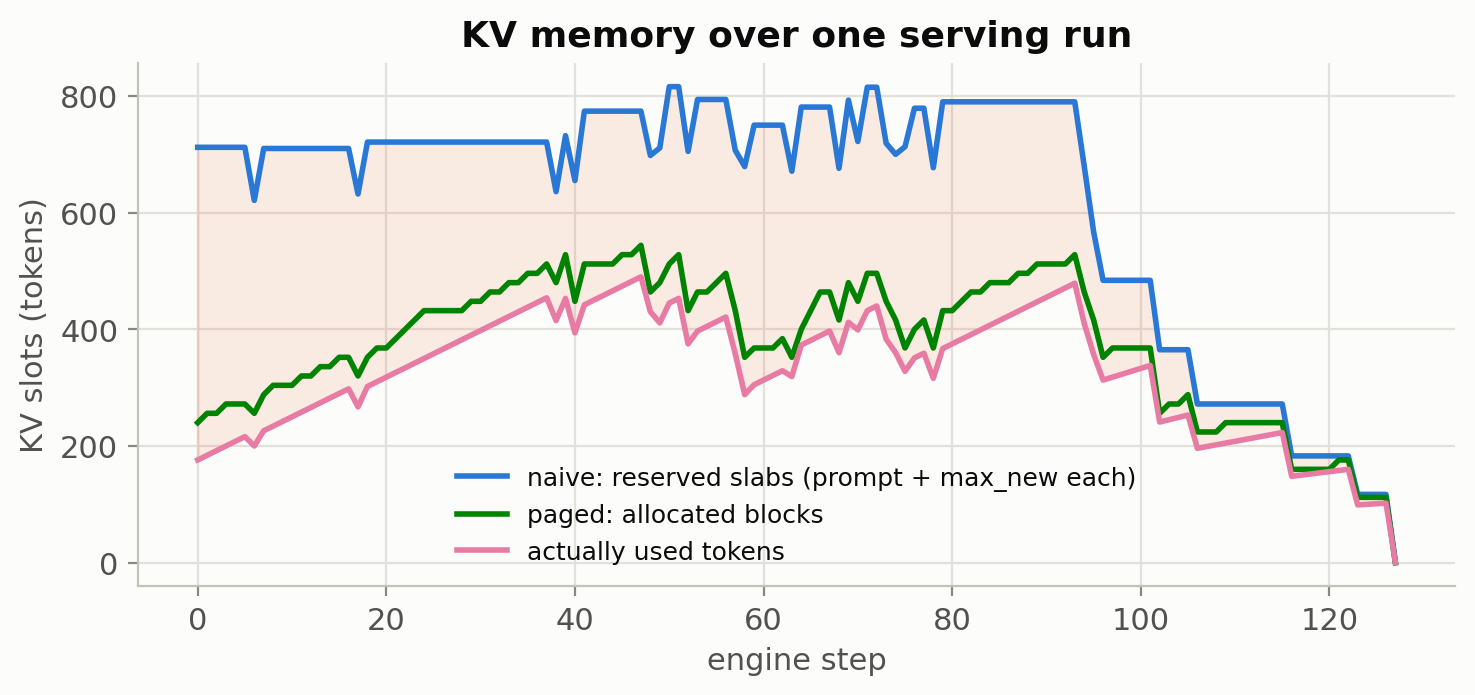

wasted KV memory — naive slabs: 48%   paged blocks: 13%


In [7]:
#| code-fold: true
#| code-summary: "Show plotting code"
engine = MiniVLLM(num_blocks=96, max_batch=8, continuous=True)
engine.submit(make_workload())
engine.run()
h = np.array(engine.history, dtype=float)

fig, ax = plt.subplots(figsize=(8.5, 3.4))
ax.plot(h[:, 1], label='naive: reserved slabs (prompt + max_new each)')
ax.plot(h[:, 2], label='paged: allocated blocks')
ax.plot(h[:, 3], label='actually used tokens')
ax.fill_between(range(len(h)), h[:, 3], h[:, 1], alpha=0.12, color='C5')
ax.set_xlabel('engine step')
ax.set_ylabel('KV slots (tokens)')
ax.set_title('KV memory over one serving run')
ax.legend(fontsize=9)
plt.show()

waste_naive = 1 - h[:, 3].sum() / h[:, 1].sum()
waste_paged = 1 - h[:, 3].sum() / h[:, 2].sum()
print(f'wasted KV memory — naive slabs: {waste_naive:.0%}   paged blocks: {waste_paged:.0%}')

The paged line hugs actual usage (the gap is only block-tail fragmentation, bounded by
15 tokens per sequence); the naive line reserves the worst case whether it's ever needed or
not. This gap is *capacity*: every wasted slot is a request that couldn't be admitted — which
is exactly where vLLM's throughput multiple comes from.

## 7. Static vs continuous batching

Same workload, same pool, same `max_batch` — only the admission policy differs. On real
hardware a decode step costs roughly the same whether the batch has 2 or 8 sequences (decode
is memory-bound on streaming the *weights* — see
[CUDA Basics §8](../05_gpu_nvidia_tools/01_cuda_basics.ipynb)), so **engine steps ≈ time**,
and occupancy is the whole game:

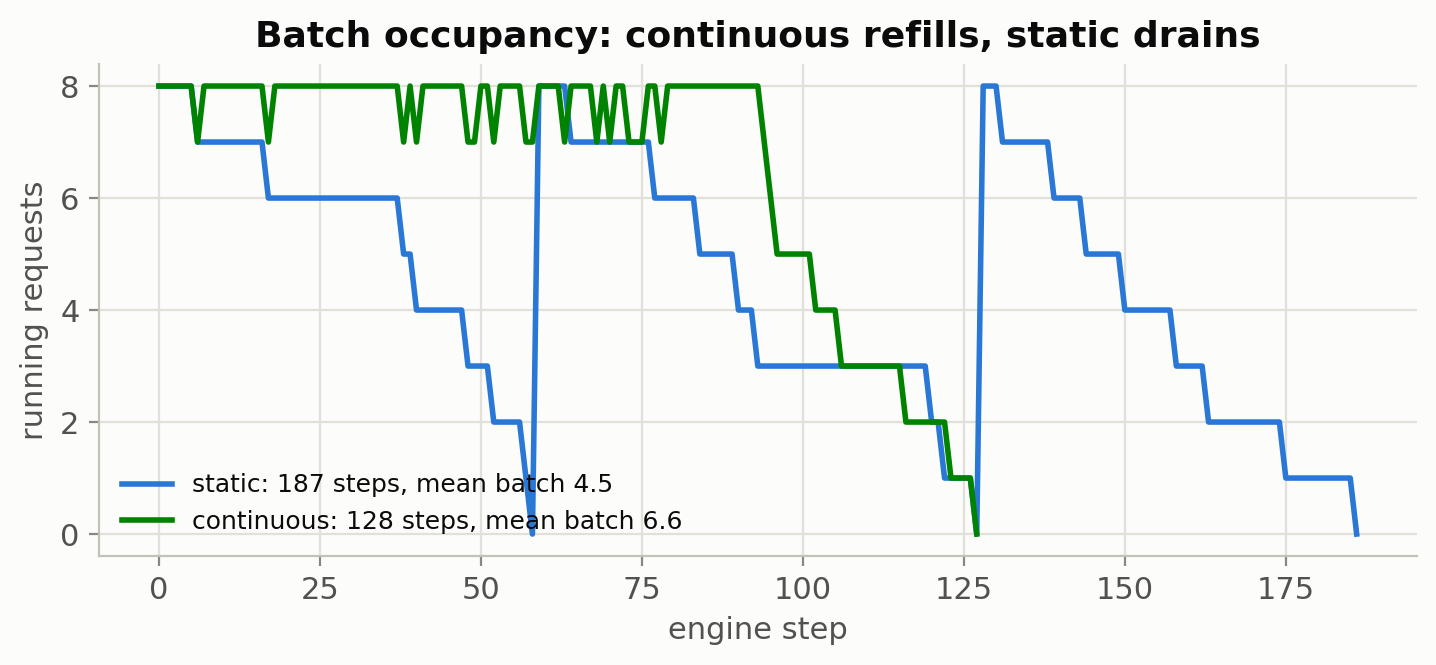

891 tokens generated either way
static:     187 steps  (wall 0.83s on CPU)
continuous: 128 steps  (wall 0.80s on CPU)
-> 1.46x fewer decode steps with continuous batching


In [8]:
#| code-fold: true
#| code-summary: "Show plotting code"
runs = {}
for mode, cont in [('static', False), ('continuous', True)]:
    eng = MiniVLLM(num_blocks=96, max_batch=8, continuous=cont)
    eng.submit(make_workload())
    t0 = time.perf_counter()
    eng.run()
    runs[mode] = (eng, time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8.5, 3.2))
for mode, (eng, _) in runs.items():
    occ = [s[0] for s in eng.history]
    ax.plot(occ, label=f'{mode}: {len(occ)} steps, mean batch {np.mean(occ):.1f}')
ax.set_xlabel('engine step')
ax.set_ylabel('running requests')
ax.set_title('Batch occupancy: continuous refills, static drains')
ax.legend(fontsize=9)
plt.show()

s_steps = len(runs['static'][0].history)
c_steps = len(runs['continuous'][0].history)
total_tokens = sum(len(r.out) for r in runs['continuous'][0].done)
print(f'{total_tokens} tokens generated either way')
print(f'static:     {s_steps} steps  (wall {runs["static"][1]:.2f}s on CPU)')
print(f'continuous: {c_steps} steps  (wall {runs["continuous"][1]:.2f}s on CPU)')
print(f'-> {s_steps / c_steps:.2f}x fewer decode steps with continuous batching')

The static engine's sawtooth is the classic pathology: each batch drains to a single
straggler before the next can start. Continuous batching holds occupancy near the cap the
whole run. (CPU wall-clock understates the win because our per-step cost *does* grow with
batch size — on a GPU it barely does, which is the point.)

## 8. Preemption: when the pool runs dry

Shrink the pool until requests genuinely don't fit. The scheduler guarantees every step can
complete by evicting the *youngest* request — freeing its blocks and requeueing it with its
generated tokens folded into the prompt for later recomputation (vLLM's recompute-preemption
policy):

In [9]:
eng = MiniVLLM(num_blocks=24, max_batch=8, continuous=True)  # deliberately starved
eng.submit(make_workload())
eng.run()
assert all(len(r.out) >= r.stop_after for r in eng.done) and len(eng.done) == 24
print(f'all 24 requests completed despite a {24 * BLOCK}-token pool; '
      f'{eng.preemptions} preemption(s) along the way')

all 24 requests completed despite a 384-token pool; 16 preemption(s) along the way


## Key Takeaways

1. **The KV cache is the serving bottleneck** — ~512 KB/token for a 7B model means the cache,
   not the weights, decides batch size.
2. **Paging turns worst-case reservation into on-demand allocation.** Waste drops from the
   naive slab's near-half share (48% measured above) to block-tail fragmentation only —
   13% here because our toy sequences are short relative to the 16-token block; at realistic
   sequence lengths it falls below 4%.
3. **PagedAttention is a gather, not new math** — attention over block-table-ordered K/V is
   bit-identical to contiguous attention (we asserted it), which is why vLLM needs no model
   changes.
4. **Continuous batching keeps the batch full.** Same tokens, 1.46x fewer decode steps here —
   and on memory-bound GPU decode, steps are time.
5. **Preemption makes overcommit safe**: evict-and-recompute trades compute for memory and
   never deadlocks — the same bet as OS swapping.
6. What real vLLM adds beyond this mini version: fused paged-attention CUDA kernels, prefix
   sharing with copy-on-write blocks, chunked prefill, and multi-GPU — the concepts are the
   ones above.

### What to read next

- The paper: [Efficient Memory Management for LLM Serving with PagedAttention](https://arxiv.org/abs/2309.06180) (Kwon et al., SOSP 2023)
- In this repo: `src/ai_playground/inference/generate.py` — the contiguous KV cache this
  chapter generalizes — and [CUDA Basics](../05_gpu_nvidia_tools/01_cuda_basics.ipynb) for
  *why* decode is memory-bound.
